<a href="https://colab.research.google.com/github/nishasn10/Graph_Project/blob/main/Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
Number of rows: 649

Logistic Regression Accuracy: 90.77 %
SVM Accuracy: 90.0 %
Naive Bayes Accuracy: 90.77 %
Decision Tree Accuracy: 88.46 %
Random Forest Accuracy: 90.0 %
K-Means Accuracy: 38.46 %
Linear Regression Accuracy: 90.77 %
Lasso Regression Accuracy: 88.46 %
Ridge Regression Accuracy: 88.46 %

FINAL MODEL COMPARISON
Logistic Regression : 90.77 %
SVM : 90.0 %
Naive Bayes : 90.77 %
Decision Tree : 88.46 %
Random Forest : 90.0 %
K-Means : 38.46 %
Linear Regression : 90.77 %
Lasso Regression : 88.46 %
Ridge Regression : 88.46 %

BEST MODEL
Logistic Regression with 90.77 %


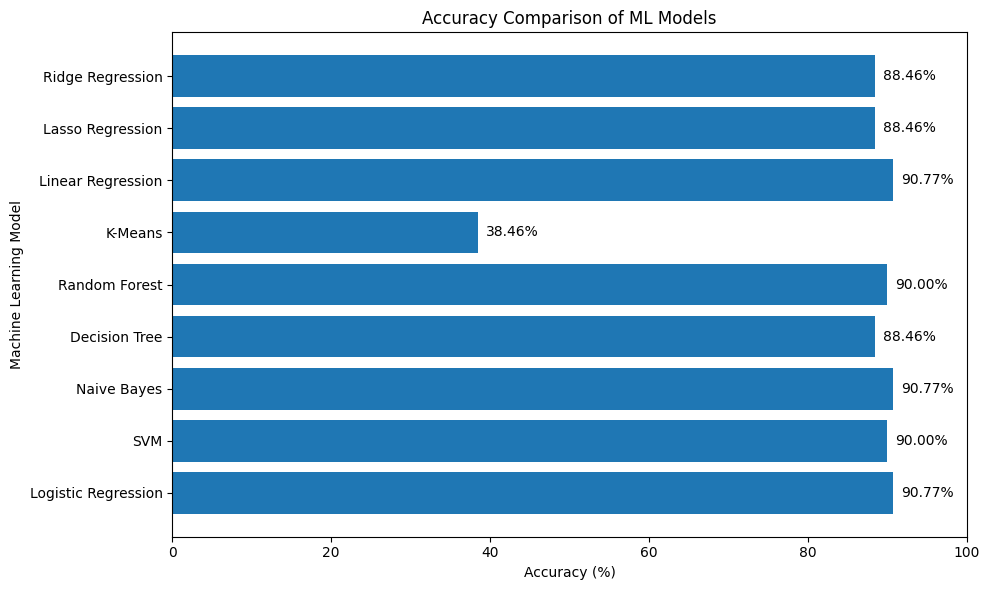

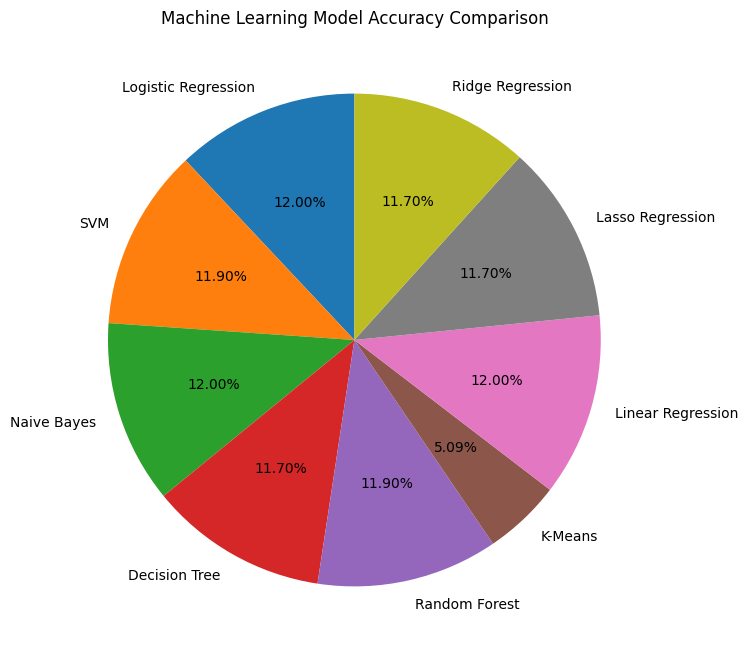

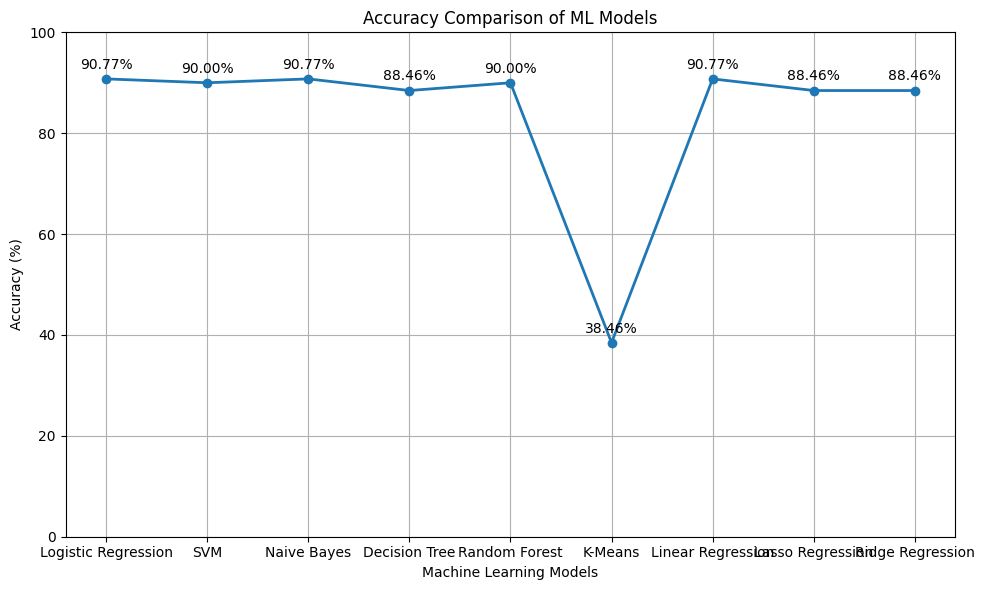

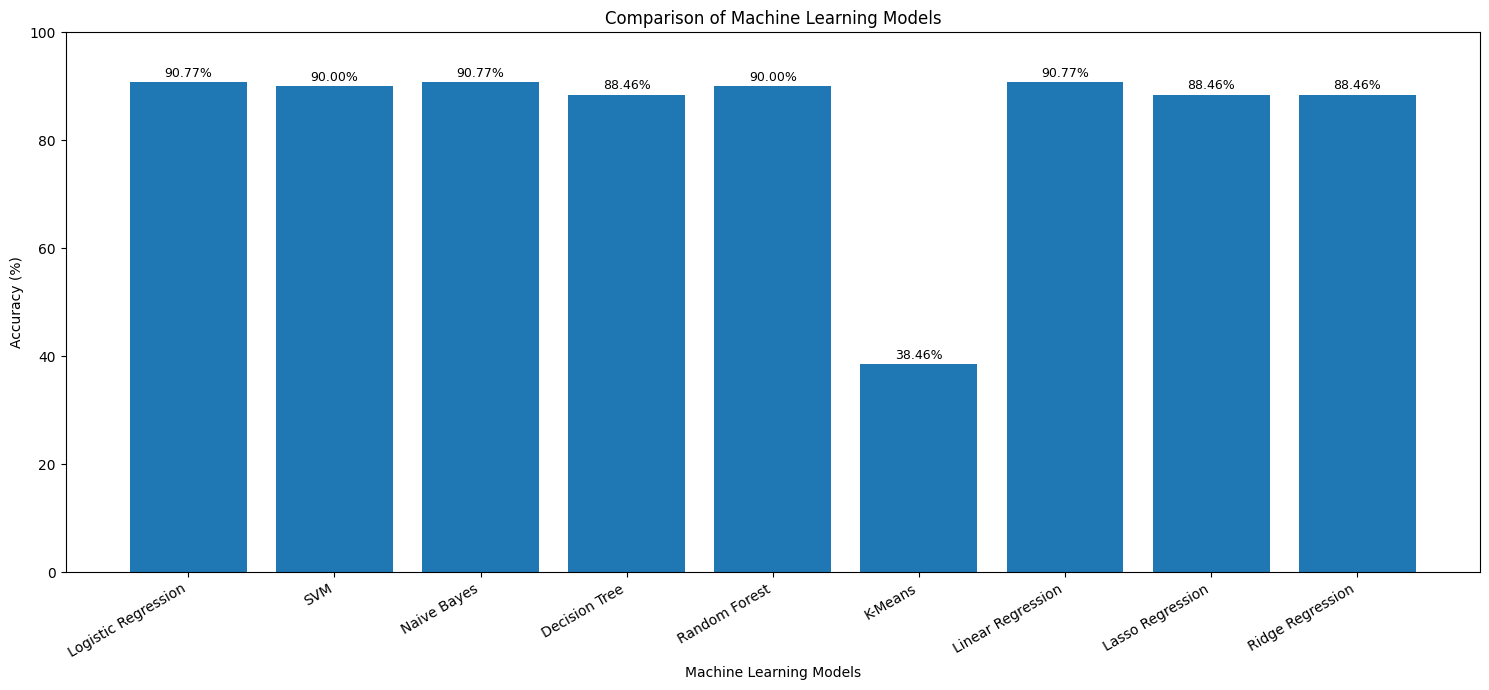

In [4]:
# ============================================
# STUDENT PERFORMANCE - MODEL COMPARISON
# Logistic Regression
# SVM
# Naive Bayes
# Decision Tree
# Random Forest
# K-Means
# Linear Regression
# Lasso Regression
# Ridge Regression
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

# Clustering Model
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import accuracy_score


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("student-por.csv", sep=",")

print("Dataset Loaded Successfully!")
print("Number of rows:", len(df))
print()


# ============================================
# 2. CREATE PASS / FAIL TARGET
# ============================================

# G3 >= 10 = Pass
# G3 < 10  = Fail

df["Pass"] = (df["G3"] >= 10).astype(int)


# ============================================
# 3. SELECT FEATURES
# ============================================

X = df[[
    "studytime",
    "absences",
    "G1",
    "G2"
]]

y = df["Pass"]


# ============================================
# 4. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================
# 5. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================
# 6. LOGISTIC REGRESSION
# ============================================

logistic_model = LogisticRegression()

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_prediction = logistic_model.predict(
    X_test_scaled
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy * 100, 2),
    "%"
)


# ============================================
# 7. SVM
# ============================================

svm_model = SVC(
    kernel="linear"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_prediction = svm_model.predict(
    X_test_scaled
)

svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print(
    "SVM Accuracy:",
    round(svm_accuracy * 100, 2),
    "%"
)


# ============================================
# 8. NAIVE BAYES
# ============================================

nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_train
)

nb_prediction = nb_model.predict(
    X_test_scaled
)

nb_accuracy = accuracy_score(
    y_test,
    nb_prediction
)

print(
    "Naive Bayes Accuracy:",
    round(nb_accuracy * 100, 2),
    "%"
)


# ============================================
# 9. DECISION TREE
# ============================================

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_prediction = decision_tree_model.predict(
    X_test
)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_prediction
)

print(
    "Decision Tree Accuracy:",
    round(decision_tree_accuracy * 100, 2),
    "%"
)


# ============================================
# 10. RANDOM FOREST
# ============================================

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_prediction = random_forest_model.predict(
    X_test
)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_prediction
)

print(
    "Random Forest Accuracy:",
    round(random_forest_accuracy * 100, 2),
    "%"
)


# ============================================
# 11. K-MEANS
# ============================================

kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_model.fit(
    X_train_scaled
)

# Predict clusters
train_clusters = kmeans_model.predict(
    X_train_scaled
)

test_clusters = kmeans_model.predict(
    X_test_scaled
)


# ============================================
# 12. MAP K-MEANS CLUSTERS TO PASS / FAIL
# ============================================

cluster_0_pass_rate = y_train[
    train_clusters == 0
].mean()

cluster_1_pass_rate = y_train[
    train_clusters == 1
].mean()


if cluster_0_pass_rate > cluster_1_pass_rate:

    kmeans_prediction = test_clusters

else:

    kmeans_prediction = 1 - test_clusters


kmeans_accuracy = accuracy_score(
    y_test,
    kmeans_prediction
)

print(
    "K-Means Accuracy:",
    round(kmeans_accuracy * 100, 2),
    "%"
)


# ============================================
# 13. LINEAR REGRESSION
# ============================================

# Here we predict the actual G3 score

y_regression = df["G3"]


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_regression,
    test_size=0.20,
    random_state=42
)


linear_model = LinearRegression()

linear_model.fit(
    X_train_reg,
    y_train_reg
)

linear_prediction = linear_model.predict(
    X_test_reg
)


# Convert predicted G3 into Pass / Fail

linear_pass_prediction = (
    linear_prediction >= 10
).astype(int)

linear_actual_pass = (
    y_test_reg >= 10
).astype(int)


linear_accuracy = accuracy_score(
    linear_actual_pass,
    linear_pass_prediction
)

print(
    "Linear Regression Accuracy:",
    round(linear_accuracy * 100, 2),
    "%"
)


# ============================================
# 14. LASSO REGRESSION
# ============================================

lasso_model = Lasso(
    alpha=0.1
)

lasso_model.fit(
    X_train_scaled,
    y_train_reg
)

lasso_prediction = lasso_model.predict(
    X_test_scaled
)


# Convert predicted G3 into Pass / Fail

lasso_pass_prediction = (
    lasso_prediction >= 10
).astype(int)

lasso_actual_pass = (
    y_test_reg >= 10
).astype(int)


lasso_accuracy = accuracy_score(
    lasso_actual_pass,
    lasso_pass_prediction
)

print(
    "Lasso Regression Accuracy:",
    round(lasso_accuracy * 100, 2),
    "%"
)


# ============================================
# 15. RIDGE REGRESSION
# ============================================

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_scaled,
    y_train_reg
)

ridge_prediction = ridge_model.predict(
    X_test_scaled
)


# Convert predicted G3 into Pass / Fail

ridge_pass_prediction = (
    ridge_prediction >= 10
).astype(int)

ridge_actual_pass = (
    y_test_reg >= 10
).astype(int)


ridge_accuracy = accuracy_score(
    ridge_actual_pass,
    ridge_pass_prediction
)

print(
    "Ridge Regression Accuracy:",
    round(ridge_accuracy * 100, 2),
    "%"
)


# ============================================
# 16. STORE ALL ACCURACIES
# ============================================

model_names = [
    "Logistic Regression",
    "SVM",
    "Naive Bayes",
    "Decision Tree",
    "Random Forest",
    "K-Means",
    "Linear Regression",
    "Lasso Regression",
    "Ridge Regression"
]


accuracies = [
    logistic_accuracy * 100,
    svm_accuracy * 100,
    nb_accuracy * 100,
    decision_tree_accuracy * 100,
    random_forest_accuracy * 100,
    kmeans_accuracy * 100,
    linear_accuracy * 100,
    lasso_accuracy * 100,
    ridge_accuracy * 100
]


# ============================================
# 17. FINAL MODEL COMPARISON
# ============================================

print("\n================================")
print("FINAL MODEL COMPARISON")
print("================================")

for name, accuracy in zip(
    model_names,
    accuracies
):

    print(
        name,
        ":",
        round(accuracy, 2),
        "%"
    )


# ============================================
# 18. FIND BEST MODEL
# ============================================

best_index = accuracies.index(
    max(accuracies)
)

best_model = model_names[best_index]

best_accuracy = accuracies[best_index]


print("\n================================")
print("BEST MODEL")
print("================================")

print(
    best_model,
    "with",
    round(best_accuracy, 2),
    "%"
)
# ============================================
# ALTERNATIVE GRAPH - HORIZONTAL BAR CHART
# ============================================

plt.figure(figsize=(10, 6))

bars = plt.barh(
    model_names,
    accuracies
)

plt.xlabel("Accuracy (%)")
plt.ylabel("Machine Learning Model")

plt.title("Accuracy Comparison of ML Models")

plt.xlim(0, 100)

# Show accuracy value at the end of each bar
for bar, accuracy in zip(bars, accuracies):

    plt.text(
        accuracy + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.2f}%",
        va="center"
    )

plt.tight_layout()

plt.show()

# ============================================
# PIE CHART - MODEL ACCURACY COMPARISON
# ============================================

plt.figure(figsize=(8, 8))

plt.pie(
    accuracies,
    labels=model_names,
    autopct="%.2f%%",
    startangle=90
)

plt.title("Machine Learning Model Accuracy Comparison")

plt.show()

# ============================================
# LINE GRAPH - MODEL ACCURACY COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    model_names,
    accuracies,
    marker="o",
    linewidth=2
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy (%)")

plt.title("Accuracy Comparison of ML Models")

plt.ylim(0, 100)

# Display accuracy values
for i, accuracy in enumerate(accuracies):

    plt.text(
        i,
        accuracy + 2,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.grid(True)

plt.tight_layout()

plt.show()

# ============================================
# 19. GRAPHICAL REPRESENTATION
# ============================================

plt.figure(
    figsize=(15, 7)
)

bars = plt.bar(
    model_names,
    accuracies
)


plt.xlabel(
    "Machine Learning Models"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.title(
    "Comparison of Machine Learning Models"
)

plt.ylim(
    0,
    100
)


# ============================================
# 20. DISPLAY ACCURACY ON TOP OF BARS
# ============================================

for bar, accuracy in zip(
    bars,
    accuracies
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center",
        fontsize=9
    )


plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

plt.show()